<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

In [3]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [2]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder. SDM is an abbreviation of Statistical Decision Making.
%cd '/content/drive/MyDrive/SDM'


ModuleNotFoundError: No module named 'google'

In [5]:
%cd '../'

/Users/minhyuk/Dropbox/PycharmProjects/statistical-decision-making


Import packages.

In [6]:
import pandas
import numpy
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm


# Stat Mini4 Script Slide Set 10
## Time Series & Forecasting

Some plot commands are fairly involved. On exams I will ask only simple questions about hist() and plot() commands.  

### Understanding Lagged Variables

With time series analysis, we often want to use past values
of a variable. The shift function in the Pandas package simplifies such analyses.  

The shift function is illustrated here.

In [7]:
# Import PghTempsMay2000.xlsx, drop missing values
PghTempsMay = pandas.read_excel("data/Pgh_May_Temps.xlsx")
PghTempsMay2000 = PghTempsMay.query("Year == 2000")

In [8]:
# Issue the following commands so that we can work with Temp
# and Day without needing to reference the data file
Temp = PghTempsMay2000["Temperature"]
Day = PghTempsMay2000["Day"]

Text(0, 0.5, 'Temperature')

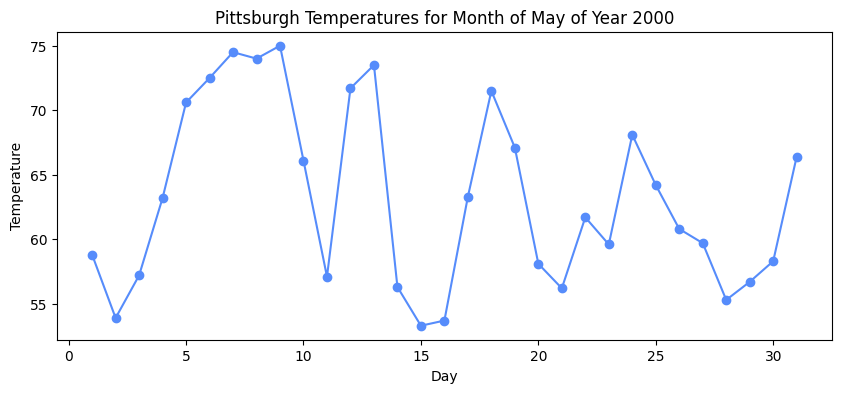

In [9]:
#  View a plot of the data with a solid line connecting the points
plt.figure(figsize=(10, 4))
plt.plot(Day, Temp)
plt.scatter(Day, Temp)
plt.title("Pittsburgh Temperatures for Month of May of Year 2000")
plt.xlabel("Day")
plt.ylabel("Temperature")

In [10]:
# Create one-period and two-period lags of temperature
TempLag1 = Temp.shift(1)
TempLag2 = Temp.shift(2)

In [11]:
# Put Day and the three temperature variables in a data.frame
TempsKeep = pandas.DataFrame({"Day": Day, "Temp": Temp, "TempLag1": TempLag1, "TempLag2": TempLag2})
# Select and print first 8 rows
first_8_rows = TempsKeep.head(8)
print(first_8_rows)

     Day  Temp  TempLag1  TempLag2
145    1  58.8       NaN       NaN
146    2  53.9      58.8       NaN
147    3  57.2      53.9      58.8
148    4  63.2      57.2      53.9
149    5  70.6      63.2      57.2
150    6  72.5      70.6      63.2
151    7  74.5      72.5      70.6
152    8  74.0      74.5      72.5


Use the lagged variables in a regression. We'll investigate whether temperatures in the previous two days are significant predictors of daily temperatures.

In [12]:
TempReg = tprstats.model("ts", "Temp~lag(Temp,1)+lag(Temp,2)", TempsKeep)
TempReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Temp   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.378
No. Observations:                  29   F-statistic:                     12.29
Covariance Type:                  HAC   Prob (F-statistic):           0.000175
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       41.0964     11.217      3.664      0.001      18.039      64.154
lag(Temp, 1)     0.7694      0.179      4.299      0.000       0.402       1.137
lag(Temp, 2)    -0.4126      0.115     -3.572      0.001      -0.650      -0.175
================================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 2 lags and without small sample correction
"""

That's it. You now know how to create, use, and interpret lagged values of a variable.

## Regression using time series data
### Coffee Data

In [13]:
# Import Coffee Dataset Coffee_Data
Coffee_Data = pandas.read_excel("data/Coffee_Data.xlsx")

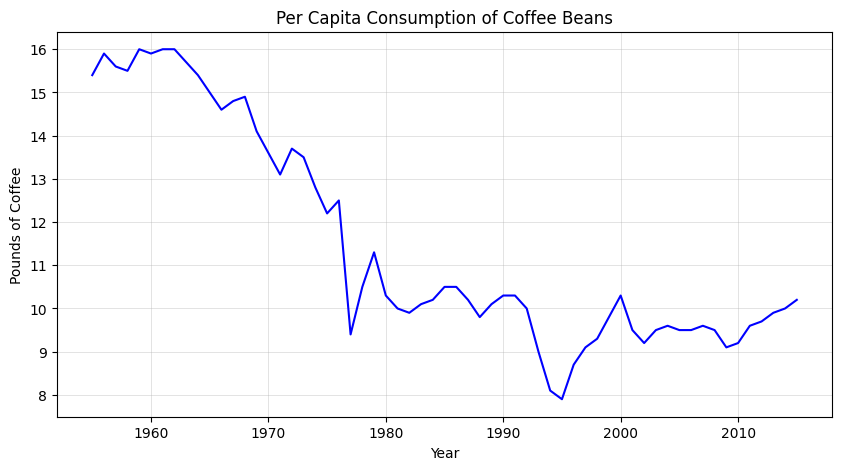

In [14]:
# Plot coffee consumption per capita
plt.figure(figsize=(10, 5))
plt.plot(Coffee_Data["year"], Coffee_Data["cons"], color="blue")
plt.title("Per Capita Consumption of Coffee Beans")
plt.xlabel("Year")
plt.ylabel("Pounds of Coffee")
plt.grid(True)

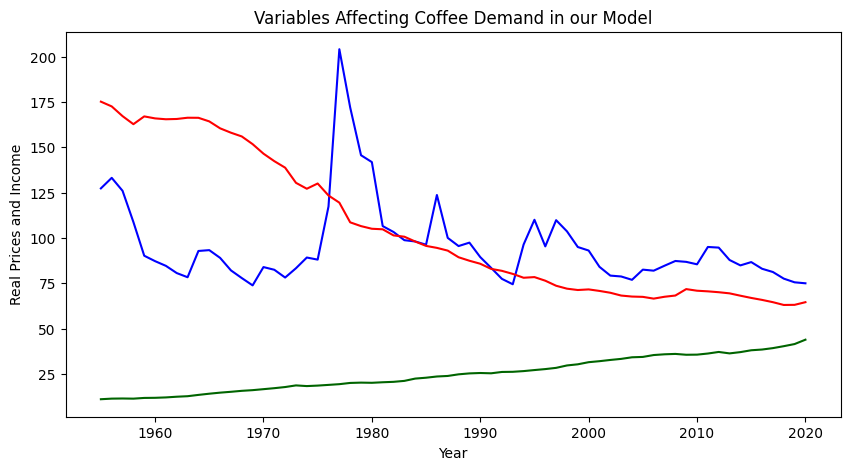

In [15]:
# Plot coffee price, per capita income, price of carbonated beverages
plt.figure(figsize=(10, 5))
plt.title("Variables Affecting Coffee Demand in our Model")
plt.xlabel("Year")
plt.ylabel("Real Prices and Income")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcofe"], color="blue")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcinc"], color="darkgreen")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcarb"], color="red")
# lines(Coffee_Data$year,Coffee_Data$cons,col="blue",lw=2)

In [16]:
Coffee_Data.describe()

,year,cons,rpcarb,rpcinc,rpcofe,rptea
count,66.000000,61.000000,66.000000,66.000000,66.000000,70.000000
mean,1987.500000,11.498361,104.806006,24.947319,95.908153,145.113044
std,19.196354,2.549084,38.677280,9.381797,23.147903,116.501996
min,1955.000000,7.900000,63.077453,11.099841,73.876182,34.802580
25%,1971.250000,9.600000,70.642227,17.347771,82.503038,52.799481
50%,1987.500000,10.200000,91.217598,24.376708,88.557200,85.249441
75%,2003.750000,13.700000,141.476738,34.003917,98.619166,240.684775
max,2020.000000,16.000000,175.189160,43.925309,204.098469,388.205618


In [17]:
# Estimate and view coffee regression.
CoffeeReg = tprstats.model("ts", "cons~rpcofe+rpcinc+rpcarb", Coffee_Data)
print(CoffeeReg.summary())

                            OLS Regression Results                            
Dep. Variable:                   cons   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.953
No. Observations:                  61   F-statistic:                     222.5
Covariance Type:                  HAC   Prob (F-statistic):           2.01e-31
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0576      1.778      0.032      0.974      -3.503       3.618
rpcofe        -0.0126      0.004     -2.933      0.005      -0.021      -0.004
rpcinc         0.1235      0.032      3.892      0.000       0.060       0.187
rpcarb         0.0901      0.008     11.947      0.000       0.075       0.105

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 2 lags and without small sample correctio

The Ramsey test gives relatively high p-values for the model we have estimated.

In [18]:
CoffeeReg.ramsey_test()

,power,pvalue
0,2,0.182315
1,3,0.372575


The scaled coefficients show that the price elasticity of demand for coffee is relatively low. This is not surprising. Most coffee drinkers are not likely to cut back consumption very much when there is a price increase.

In [ ]:
CoffeeReg.scaled_coefficients()

In [ ]:
# The following creates a variable with years through 2015
# This will be used in the plot below.
years_lt_2016 = Coffee_Data.loc[Coffee_Data["year"] < 2016, "year"]


In [ ]:
# Calculate  residuals from coffee regression
cofresid = CoffeeReg.resid

In [ ]:
# Put year and residuals in a data frame named df
df = pandas.DataFrame({
    "year": years_lt_2016,
    "resid": cofresid
})


In [ ]:
# Plot residuals by versus year
plt.plot(df["year"], df["resid"],color="black")
plt.scatter(df["year"], df["resid"], color="black", s=25)
plt.axhline(0,color="blue",linestyle="-")
plt.title("Residuals by Year")
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.show()


The leverage plots suggest no issues with our chosen model.

In [ ]:
# Display leverage plots
fig = plt.figure(figsize=(12, 6))
sm.graphics.plot_partregress_grid(CoffeeReg, fig=fig)
plt.show()

The plot below shows actual and predicted consumption and 95% prediction intervals for the data used in estimating our model. Further below a plot is presented with predicted values for five years beyond this plot. As shown by the commands used for the plot, it is straightforward to create the plot.

In [ ]:
plt.figure(figsize=(10, 5))
CoffeeReg.plot_actual_fitted()

The file named Coffee_Predictors has rpcofe, rpcarb, and rpcinc for the time period of our data (1955 to 2015) and for the additional years 2016 through 2020. Thus, we can use our model to predict consumption for years 1955 through 2020.

In [ ]:
# Read Coffee_Predictors.xlsx and calculate predictions and prediction intervals
Coffee_Predictors = pandas.read_excel("data/Coffee_Predictors.xlsx")
Pred_and_PI=CoffeeReg.prediction_intervals(Coffee_Predictors, alpha=0.05)

The command below combines the data for year and actual consumption with the data for the predicted values and 95% prediction interval.

In [ ]:
CofDatPred = pandas.concat([Coffee.iloc[:, :2], Pred_and_PI], axis=1)

The graph below has the same color formatting as the graph above. However, this graph provides the predicted values and prediction intervals for five years beyond the years for which consumption data are available. From the graph, we see that the predictions point to a slight uptick in demand. Data for the predictor variables are not available beyond year 2020, but the results in the graph below suggest that the period of decline in coffee demand has ended.

In [ ]:

# These commands plot the actual and fitted values for the coffee data as well as prediction and 95% prediction intervals.
ax = CofDatPred.plot(x=CofDatPred.columns[0], figsize=(10,6), grid=True, legend=False)

lines = ax.lines

# First plotted series → dots
lines[0].set_linestyle('None')
lines[0].set_marker('o')
ax.lines[0].set_color('black')   # ← change dot color
ax.lines[0].set_linestyle('-')
# Last two series → same color
same_color = 'blue'
lines[-1].set_color(same_color)
lines[-2].set_color(same_color)


# Change the middle line to blue
ax.lines[1].set_color('red')
ax.lines[1].set_linestyle('--')
ax.lines[1].set_linewidth(2.5)   # ← increase width

ax.set_title('Actual (Black), Fitted (Red), Prediction Intervals (Blue), and Prediction for Five Years (Red)')
plt.xlabel('Year')
plt.ylabel('Pounds Per Capita')
plt.show()


The following estimates the model with a first-order autoregressive error. The estimated autocorrelation coefficient is .5497. The coefficient is significant at the 5% level. If you compare these results to the results from the model above, you will see that the coefficients of the variables are little changed.

In [ ]:
# Estimate with first-order autoregressive errors.
# First-order autogressive the default in the tprstats arima implementation
cof_arima = tprstats.model("arima", "cons~rpcofe+rpcinc+rpcarb", Coffee_Data)
print(cof_arima.summary())

Lets now estimate the model with variables in log form.

In [ ]:
LogReg=tprstats.model("ts","log(cons)~log(rpcofe)+log(rpcinc)+log(rpcarb)",Coffee_Data)
print(LogReg.summary())

In [ ]:
LogReg.ramsey_test()

In [ ]:
LogReg2=tprstats.model("ts","log(cons)~log(rpcofe)+log(rpcinc)+log(rpcarb)+log(rptea)",Coffee_Data)
print(LogReg2.summary())

##Another Application
###Credit Card and Treasury Interest Rates

Earlier in the course I asked you to estimate a regression model with change in credit card interest rates (dCredcrd) as the dependent variable and change in treasury interest rates (dTreas) as the independent variable. The regression below repeats the regression you did. We obtain an estimated coefficient was .558.  
Why not estimate a model with credit card interest rates (Credcrd) as the dependent variable and treasury interest rates (Treas) as the independent variable?   

Let's import the credit care data and investigate.

Here is the model you estimated in the assignment.

In [ ]:
#Import CCData_2001_2025
CCData_2001_2025=pandas.read_excel("data/CCData_2001_2025.xlsx")

In [ ]:
dCredReg=tprstats.model("ts","dCredcrd~dTreas",CCData_2001_2025)
print(dCredReg.summary())

Now estimate with the variables in levels rather than differences.  

From the regression below, we see that the coefficient of Treas is .9766 which is close to 1. From this regression, we would have concluded that the credit card interest rates follow very closely treasury rates.  
Why the difference in the result below relative to the .558 estimate we obtained just above? The answer is that the error terms in the regression below are highly correlated with each other, as demonstrated next.

In [ ]:
# Estimate and view credit card regression.
CredReg = tprstats.model("ts", "Credcrd~Treas", CCData_2001_2025)
print(CredReg.summary())

The commands below estimated the regression with first-order autoregressive errors. We see that the AR(1) coefficient is .9921. The coefficient of Treas is .5620. This is close to the estimate above, but notice that the standard error of Treas below is .048 whereas the standard error fo dTreas above is .226. The standard error in the regression below is biased downward.
The message of this example is that an AR(1) coefficient close to 1 is a signal that you should probably estimate your model with differences.  

A former Tepper MBA student had a summer internship with for a US company that exported goods overseas. Let's name this company AMR. Suppose people in country M purchase goods from AMR. If exchange rate between the US and country M changes with the dollar rising relative to the foreign currency. This makes the goods from AMR more expensive in country M. Our student was asked to estimate a demand function for each of several products that AMR exported to country M. She determined that the appropriate regression for each exported product was to use the change in sales of the product as the dependent variable and the change in the exchange rate as the independent variable. She did such an analysis for many goods exported by AMR. The company was very impressed by her work and recruited her for a fulltime position when she graduated from Tepper.

In [ ]:
# Estimate with first-order autoregressive errors.
# First-order autogressive the default in the tprstats arima implementation
CredReg_arima = tprstats.model("arima", "Credcrd~Treas", CCData_2001_2025)
print(CredReg_arima.summary())